# Del 2 - Fördjupning och Pipeline
## I denna del 2 fortsätter jag arbetet från del 1 och bygger vidare med:
- strukturering av kod via funktioner och en klass
- undersökning av sambandet mellan variabler med linjär regression
- moduler i mappen scr/
- test av en mer avancerad metod (PCA) för att se om det finns mönster i datan
- en ny analys + visualisering
- dokumentation och förklaringar 

## Frågor jag gärna vill hitta svar till:
- Vilka faktorer påverkar blodtrycket mest?
- Finns det skillnader i sjukdomsförekomst mellan män och kvinnor?
- Finns det mönster i hälsodatan när man tittar på flera faktorer samtidigt?

Här börjar jag med att ladda in datan igen samt sätter en slump-seed för reproducerbarhet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv("data/health_study_dataset.csv")

df.head(3)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


### Datakvalite:
Jag använder min klass för att kontrollera om det finns saknade värden eller duplicerade rader i datan.

In [2]:
from scipy import stats
from math import sqrt

from scr.health_analyzer import HealthAnalyzer

analyzer =  HealthAnalyzer(df)

In [3]:
analyzer.check_data_quality()

Saknade värden per kolumn:
id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64

Finns duplicerade rader?:
False


Beräknar grundstatistik (medel, median, min, max) för valda kolumner: ["age", "weight", "height", "systolic_bp", "cholesterol"]

In [4]:
cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
analyzer.basic_info(cols)

,age,weight,height,systolic_bp,cholesterol
mean,49.42625,73.413,171.84925,149.178625,4.92915
median,50.00000,73.200,171.35000,149.400000,4.97000
min,18.00000,33.700,144.40000,106.800000,2.50000
max,90.00000,114.400,200.40000,185.900000,7.88000


### Utifrån tabellen kan jag se att:
- Deltagarnas **ålder varierar mellan 18 och 90 år** alltså både unga och äldre personer.
- Systoliskt blodtryck ligger i genomsnitt runt **149 mmHG** vilket är lite högre än normalt (120-130). Kan det betyda en högriskgrupp?
- Kolesterolvärderna varierar mycket mellan individer.
- Medianvärdena ligger nära medelvärdena, det kan betyda att det **inte finns några extrema outliers** i datan.
- Det finns stor variation i flera variabler vilket är bra om man ska analysera vidare med regression eller PCA.

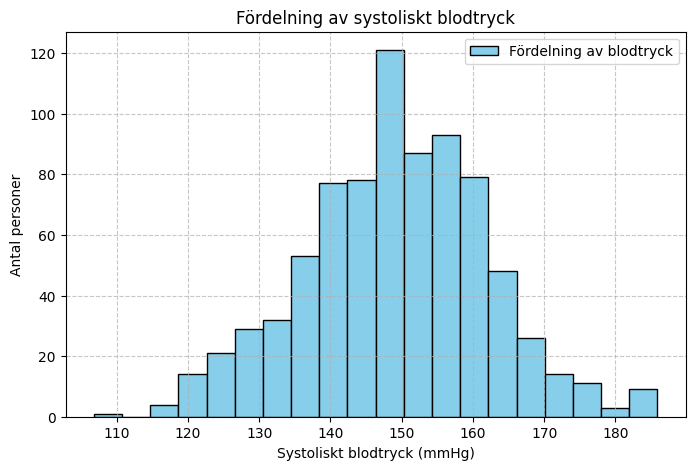

In [5]:
analyzer.plot_bp_histogram()

### Histogrammet visar hur blodtrycket är fördelat bland deltagarna i studien:
- Dem flesta ligger mellan **140-160 mmHg**, vilket är högre än normalt.
- Formen på grafen liknar en **normalfördelning**, vilket är bra för mina vidare analyser. 
- Det finns några värden över 170-180 mmHg som kan tyda på riskgrupp med högt blodtryck.
- Nästan inga personer har värden under 115 mmHg, så blodtrycket verkar generellt vara ganska högt i denna studie. 

Jag flyttade alltså delar från min del 1 av uppgiften genom att skapa en klass HealthAnalyzer och använda mig utav funktioner och moduler.

### Korrelationsanalys
Innan jag gör regression eller PCA vill jag undersöka om variablerna hänger ihop. En sådan matris visar hur starkt variablerna påverkar varandra. 

                  age    weight    height  systolic_bp  cholesterol
age          1.000000 -0.017309 -0.004653     0.607578     0.491173
weight      -0.017309  1.000000  0.320260     0.179467     0.256214
height      -0.004653  0.320260  1.000000     0.086297    -0.043344
systolic_bp  0.607578  0.179467  0.086297     1.000000     0.368441
cholesterol  0.491173  0.256214 -0.043344     0.368441     1.000000


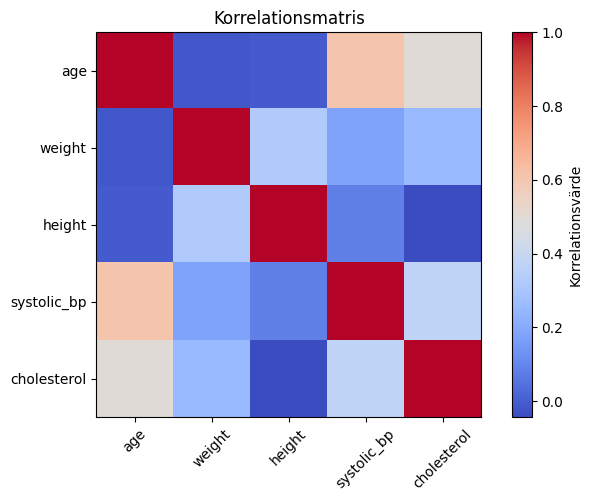

In [6]:
analyzer.show_correlations()

### Vad ser jag utifrån matrisen:
- **Längd och vikt verkar inte påverka blodtrycket så mycket**, lite oväntat.
- Blodtryck i detta dataset kanske främst påverkas av **ålder och kolesterol**.
- **Åldern har störst samband med blodtryck** men även kolesterol har ett tydligt samband, viktigt. 

Jag använde just denna korrelationsmatris för att se vilka variabler som eventuellt kunde påverka blodtrycket. Utifrån det valde jag vilka variabler som skulle testas vidare i regressionen. 

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
model, r2 = analyzer.fit_bp_regression(["age", "weight"])
print("Intercept:", model.intercept_)
print("Koefficienter:", model.coef_)
print("R^2", r2)

Intercept: 109.49908144566373
Koefficienter: [0.53892763 0.17765752]
R^2 0.4052560814611623


### Vad kan jag se utifrån den linjära regressionen ? 
Med hjälp av den modellen försöker jag förutsäga blodtryck utifrån ålder och vikt.

- **Intercept** är då grudnivå på blodtrycket när ålder och vikt är 0. Det är mest för det teoretiska, men ingår i modellen.
- **Koefficienter** visar ungefär hur mycket blodtrycket ändras, när åldern eller vikten ökar med 1 enhet, om det andra hålls konstant.
- **R²-värdet** som ligger runt 0.40 betyder att modellen förklarar cirka 40% av variationen i blodtrycket. Resten beror på slump eller andra faktorer. 

Jag använde LinearRegression från scikit-learn som bygger en sådan modell med hjälp av linjär algebra. 
Dokumentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

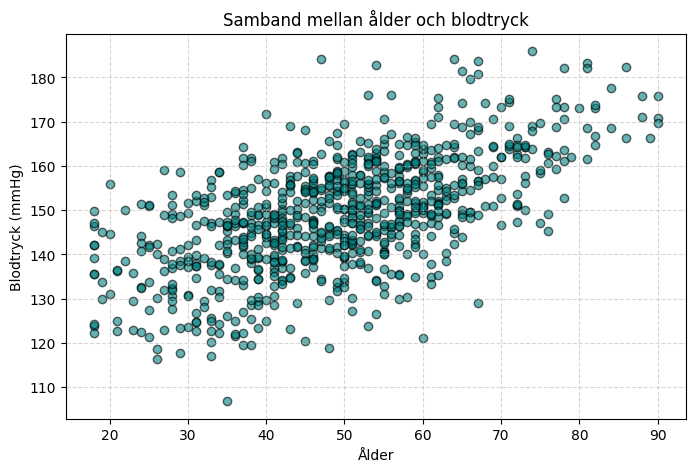

In [9]:
analyzer.plot_age_vs_bp()

### Här undersöker jag sambandet mellan ålder och systoliskt blodtryck. Varje punkt är en person i datasättet.

 Jag ser att:
- det finns en trend : **blodtrycket ökar oftast med åldern**
- unga deltagare (20-40 år) har blodtryck runt **120-145 mmHG**
- äldre personer (60+ år) ligger oftare högre, ibland över **170 mmHG**
- spridningen inom varje åldersgrupp är ganska stor, vilket måste betyda att åldern inte förklarar variationen i blodtrycket
- grafen stödjer faktiskt min resultat från regression-modellen där jag fick fram **R² värde på ca 0.40**, alltså ungefär 40% av variationen kan förklaras av ålder och vikt.

Slutsats: **Äldre personer trenderar att ha högre blodtryck, men ålder är inte den enda faktorn som påverkar (andra faktorer kan vara gener, livskvalite, sjukdommar,mm.)**

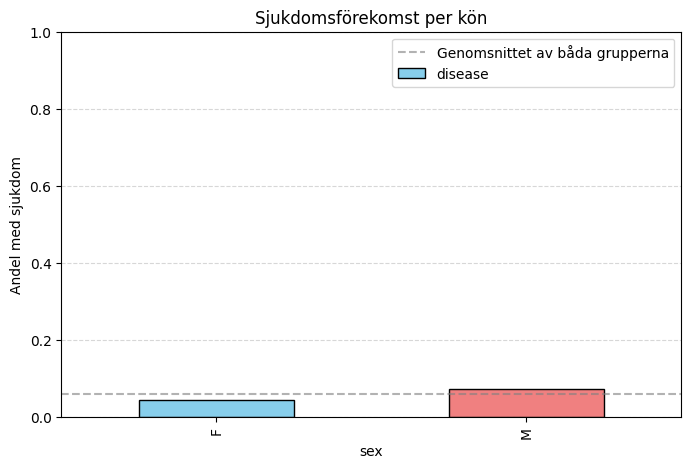

In [10]:
analyzer.plot_disease_rate_by_sex()

### Här jämför jag hur stor andel av deltagarna i undersökningen som har sjukdomen (disease = 1) uppdelat per kön.

Stapeldiagrammet visar bla. att:
- Båda grupperna har **en låg sjukdomsförekomst**.
- Män verkar ha något större andel sjukdom än kvinnor.
- Skillnaden mellan staplarna är inte särskilt stor, som tyder på att **kön inte är den största faktorn**. Det kan tex. vara ålder, vikt eller blodtryck som har större påverkan och betydelse. 

Grafen gav mig en helhetsperspektiv, men man kan göra mer avancerade analyser. 

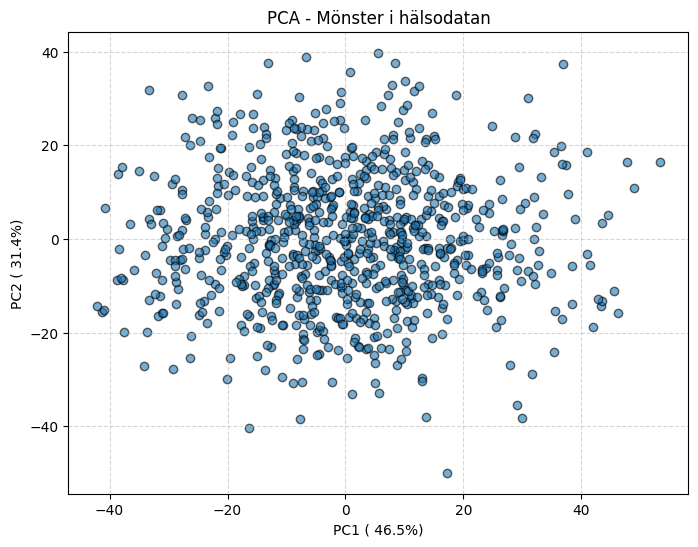

In [11]:
analyzer.plot_pca()

### PCA - Analys av mönster i hälsodatan:

- **PCA (betyder: Principal Component Analysis)** är en metod som används för att hitta mönster i datan och se om det finns grupper / trender baserat på flera variabler samtidigt (tex. ålder, vikt, längd, kolesterol och blodtryck).
- Som man ser på grafen, så har jag reducerat/ delat upp datan till två huvudkomponenter (PC1 och PC2), som tillsammans förklarar en del av variationen i datasetet. Varje punkt representerar en person i studien.

### Vad kan jag se utifrån grafen:
- Punkterna är **ganska spridda**, vilket betyder att variationen i hälsodatan inte kan beskrivas av en enda faktor. 
- Däremot verkar det finnas en **svag riktning (trend)** i mönstret, vilket betyder att några variabler påverkar mer än andra. 
- Det finns **ingen tydlig kluster-indelning** vilket tyder på att det inte finns två tydliga grupper, tex. friska vs sjuka.
- Jag tror att för att förstå hälsodatan bättre, skulle vi behöva få fler faktorer, tex. livsstil, kost, träning.

## Regression försöker förutsäga ett värde (i det här fallet blodtryck), medan PCA inte förutsäger något utan försöker hitta mönster i datan. Tillsammans ger de både förståelse och förutsägelse.

### Källor:
- **Linjär regression:** scikit-learns dokumentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- **PCA:**  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- **YouTube video:** #Dataanalys med Python. Jag fick en stor nytta av lärarens video, där jag verkligen kände att "polletten trillade ner" och jag fick en helhetsbild, samt en förståelse för hela kursen som snart är över. https://www.youtube.com/watch?v=UVO13ZNn_10
- Ställde en hel del frågor till ChatGpt för att få bättre förståelse för vad som förväntas av mig i uppgiften, fick vissa "ord" i koder förklarade men även diskuterade med AI fram och tillbaka för att få en bättre förståelse för när i det verkliga livet som Data Scientist kommer jag att ha nytta av tex. linjär regression, PCA, hur viktigt är det att faktiskt jobba i klasser istället för att leverera allt i en notebook, mm. 
- Inspiration för projektstruktur: https://www.python.org/dev/peps/pep-0008/ och inspiration från lärarens video #29 EDA med Python: https://www.youtube.com/watch?v=KU5mmZRB15E